# Longitudinal trajectory classification — common notebook (adapter-driven)

One model-agnostic notebook for every longitudinal trajectory experiment. The
per-model logic lives in an **adapter** (`CLASSIFIER/adapters/`) selected by the
`ADAPTER` parameter (defaults to `MODEL`); the SHARED cells below call only the
six contract hooks plus `common/` utilities, so they are identical across models.

GELSTM / GEGRU and the GEC-MLP are covered by two adapters; FDR and GRU are config
flags (`use_fdr`, `rnn_type`), not separate notebooks. Driven by `run_experiment.py`
via `the experiments/ directory`; also runnable standalone (interactive prompts preserved).

In [1]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint/threshold prompts).
EXPERIMENT_ID = None
MODE = None
MODEL = None
ADAPTER = None                # adapter registry key; None -> defaults to MODEL
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None        # required when THRESHOLD_MODE is fixed
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to a common-notebook checkpoints dir when standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict (dataclass < json < hyperparams)
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name

In [2]:
# Parameters
EXPERIMENT_ID = "ext-oasis3-braintokengt-stabilized-seed45"
MODE = "longitudinal"
MODEL = "BrainTokenGT"
DATASET = "OASIS3_WHOLE_BRAIN"
SEED = 45
GAAE_CHECKPOINT_PATH = "notebooks/checkpoints/checkpoints_gaae_whole_brain/ethereal-planet-16_2026-06-10_12-31-05/model_ethereal-planet-16_2026-06-10_12-31-05.pth"
THRESHOLD_MODE = "best-f1"
FIXED_THRESHOLD = None
WANDB_ENABLED = True
OUTPUT_DIR = "outputs/ext-oasis3-braintokengt-stabilized-seed45"
RESOLVED_CONFIG = {"_comment": "Brain-TokenGT REPAIRED + fix-stabilized: same fidelity flags as braintokengt_repaired_delcode.json, but the newly-unfrozen GIVE/GRCU parameters (train_give=true) get their own optimizer param group -- give_weight_decay regularizes the recurrent weight-matrix GRU, give_lr_scale slows its evolution -- to address the run-to-run numerical divergence documented in outputs/braintokengt-delcode-whole-brain-repaired (two failed runs, IndexError in TopK from non-finite scores; isolated replay showed it is GPU floating-point-order sensitive, not data-dependent).", "in_features": 200, "num_nodes": 200, "output_sizes": [32, 32], "nhead": 2, "num_layers": 2, "static_edge_topk": 180, "edge_weight_mode": "weighted", "readout": "graph_token", "force_single_head": False, "train_give": True, "give_weight_decay": 0.001, "give_lr_scale": 0.1, "edge_density": 0.15012345679012346, "adjacency_metric": "raw", "min_visits": 2, "max_visits": 3, "optimizer": "Adam", "learning_rate": 0.001, "weight_decay": 0.0, "epochs": 50, "early_stopping_patience": 15, "batch_size": 8, "use_class_cost_weights": True, "grad_clip": 1.0, "n_folds": 5, "cohort": "oasis3"}
RUN_DIR = "/mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/ext-oasis3-braintokengt-stabilized-seed45/runs/morning-pebble-1-4b9f6d895-2026-08-22_20-50-53"
RUN_NAME = "morning-pebble-1-4b9f6d895-2026-08-22_20-50-53"
ADAPTER = "braintokengt"


## Pipeline overview

`set_seed` → load splits → `prepare_data` (HOOK) → `build_model` (HOOK) →
`run_kfold_cv` (drives `train_fold` HOOK) → `select_oof_threshold` → `save_run` →
test (`eval_split` HOOK) → ROC → `early_detection_table` (`truncate_to_n_visits`) →
`trajectory_frame` (`per_visit_probs`).

In [3]:
import sys
from pathlib import Path
repo_root = Path('/mnt/e/fyassine/ad-early-detection')
model_root = Path('/mnt/e/fyassine/ad-early-detection/CLASSIFIER')
if str(model_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
    sys.path.insert(0, str(model_root))

In [4]:
# reproducibility seeding — must run before datasets, samplers, or models.
from SHARED.seeding import (
    set_seed, make_rng, make_torch_generator, seed_worker,
)
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

In [5]:
import json, os, copy, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import classification_report

# Shared, model-agnostic utilities (the lifted notebook logic — reuse, do not inline).
from common.checkpoints import select_gaae_checkpoint
from SHARED.sanity import run_full_audit
from SHARED import tracking
from SHARED.provenance import region_from_data_root
from common.crossval import Bundle, run_kfold_cv, summarize_cv
from common.thresholds import select_oof_threshold
from common.plots import plot_oof_test_roc, plot_conversion_trajectories
from common.early_detection import early_detection_table, trajectory_frame
from common.run_artifacts import save_run, record_test_metrics
from adapters import get_adapter

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Configuration

In [7]:
from DATA.DELCODE.src.splitting.load_splits import splits_dir, split_csv_paths

# ── Paths ────────────────────────────────────────────────────────────────
dataset_str = str(DATASET or '').upper()
if 'ADNI' in dataset_str:
    WB_DATA_ROOT = str(repo_root / 'DATA/ADNI/__fc_wholebrain_sch200_flat__/matrices')
    METADATA_DIR = str(repo_root / 'DATA/ADNI/__metadata__')
    COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohort_manifest.csv')
    SPLITS_DIR   = os.path.join(METADATA_DIR, 'SPLITS', 'downstream')
    TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
    VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
    TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')
    cohort_tag   = 'adni'
elif 'OASIS' in dataset_str:
    WB_DATA_ROOT = str(repo_root / 'DATA/OASIS3/__fc_wholebrain_sch200_flat__/matrices')
    METADATA_DIR = str(repo_root / 'DATA/OASIS3/__metadata__')
    COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohort_manifest.csv')
    SPLITS_DIR   = os.path.join(METADATA_DIR, 'SPLITS', 'downstream')
    TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
    VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
    TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')
    cohort_tag   = 'oasis3'
else:
    WB_DATA_ROOT = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/matrices'
    METADATA_DIR = '/mnt/e/fyassine/ad-early-detection/DATA/DELCODE/__fc_wholebrain_sch200_flat__/metadata'
    COHORTS_CSV  = os.path.join(METADATA_DIR, 'cohorts_with_scans_on_disk.csv')
    SPLITS_DIR   = str(splits_dir('downstream'))
    TRAIN_CSV    = os.path.join(SPLITS_DIR, 'train.csv')
    VAL_CSV      = os.path.join(SPLITS_DIR, 'val.csv')
    TEST_CSV     = os.path.join(SPLITS_DIR, 'test.csv')
    cohort_tag   = 'delcode'

DATA_INFO = region_from_data_root(WB_DATA_ROOT)
REGION    = DATA_INFO['region']
print(f"Input data: cohort={cohort_tag} region={DATA_INFO['region']}  atlas={DATA_INFO['atlas']}  ({DATA_INFO['dataset_dir']})")

CHECKPOINT_SEARCH_DIRS = [
    str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_gaae_whole_brain'),
]
if OUTPUT_DIR is None:
    OUTPUT_DIR = str(model_root / 'notebooks' / 'checkpoints' / 'checkpoints_longitudinal_common')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# GAAE encoder config (must match the checkpoint).
CONFIG_PATH = model_root / 'configs' / 'gaae_delcode_whole_brain.json'

# Training hyperparameters come entirely from the runner (RESOLVED_CONFIG = dataclass
# defaults < config_path json < hyperparams). Standalone use without a config falls
# back to each adapter's typed defaults.
TRAIN_CONFIG = dict(RESOLVED_CONFIG) if RESOLVED_CONFIG else {}
TRAIN_CONFIG.setdefault('cohort', cohort_tag)
N_FOLDS = int(TRAIN_CONFIG.get('n_folds', 5))
print('Config set.  TRAIN_CONFIG keys:', sorted(TRAIN_CONFIG))


Input data: cohort=oasis3 region=wholebrain  atlas=sch200  (__fc_wholebrain_sch200_flat__)
Config set.  TRAIN_CONFIG keys: ['_comment', 'adjacency_metric', 'batch_size', 'cohort', 'early_stopping_patience', 'edge_density', 'edge_weight_mode', 'epochs', 'force_single_head', 'give_lr_scale', 'give_weight_decay', 'grad_clip', 'in_features', 'learning_rate', 'max_visits', 'min_visits', 'n_folds', 'nhead', 'num_layers', 'num_nodes', 'optimizer', 'output_sizes', 'readout', 'static_edge_topk', 'train_give', 'use_class_cost_weights', 'weight_decay']


In [8]:
# split-hygiene audit — hard-fails if any subject crosses splits.
_ = run_full_audit({'train': TRAIN_CSV, 'val': VAL_CSV, 'test': TEST_CSV})


[SANITY] Split sizes: {'train': 35, 'val': 12, 'test': 13}
[SANITY] Pairwise-disjoint: OK


## Select GAAE Checkpoint

In [9]:
# Shared helper: resolves GAAE_CHECKPOINT_PATH headlessly under the runner, or
# prompts for an index interactively.
enc_init = str(TRAIN_CONFIG.get('encoder_init', '')).lower()
adapter_tag = str(ADAPTER or MODEL or '').lower()
needs_gaae = not (enc_init == 'none' or adapter_tag == 'braintokengt')
if needs_gaae and GAAE_CHECKPOINT_PATH is None and RUN_DIR is not None:
    raise ValueError(
        "GAAE_CHECKPOINT_PATH is required under the experiment runner. "
        "Set 'checkpoint_path:' on this entry in the experiments/ directory."
    )
if GAAE_CHECKPOINT_PATH is not None or needs_gaae:
    GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = select_gaae_checkpoint(
        CHECKPOINT_SEARCH_DIRS, checkpoint_path=GAAE_CHECKPOINT_PATH,
    )
    GAAE_CKPT_PATH = str(GAAE_CKPT_PATH)
    print(f'Selected GAAE: {GAAE_RUN_NAME}')
else:
    GAAE_RUN_NAME, GAAE_CKPT_PATH, GAAE_RUN_DIR = 'none', None, None
    print('GAAE checkpoint not required (end-to-end / raw FC baseline).')


Selected (non-interactive): ethereal-planet-16_2026-06-10_12-31-05
Selected GAAE: ethereal-planet-16_2026-06-10_12-31-05


In [10]:
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f: hp = json.load(f)
    print('GAAE config:', hp)
else:
    hp = dict(latent_dim=64, hidden_dim=128, num_heads=2, cond_dim=2, dropout=0.3,
              adjacency_k=8, file_variant='z_transformed')
    print('GAAE config not found — using defaults.')

GAAE config: {'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001, 'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25, 'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'}


## Model adapter

`get_adapter(ADAPTER or MODEL)` resolves the per-model adapter (instantiated with the
GAAE checkpoint, GAAE config, merged training config, and data paths). Its six bound
methods are aliased to the contract-hook names the SHARED cells call.

In [11]:
adapter = get_adapter(ADAPTER or MODEL)(
    gaae_ckpt_path=GAAE_CKPT_PATH, gaae_hp=hp, train_config=TRAIN_CONFIG,
    data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=rng,
)
print(f'Adapter: {type(adapter).__name__}  (key={ADAPTER or MODEL})  model_tag={adapter.model_tag}')

# Bind the six contract hooks so every SHARED cell below stays model-agnostic.
build_model          = adapter.build_model
prepare_data         = adapter.prepare_data
train_fold           = adapter.train_fold
eval_split           = adapter.eval_split
truncate_to_n_visits = adapter.truncate_to_n_visits
per_visit_probs      = adapter.per_visit_probs

Adapter: BrainTokenGTAdapter  (key=braintokengt)  model_tag=braintokengt


In [12]:
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

# CV pool = train + val; test held out.
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
diag_col = 'diagnosis' if 'diagnosis' in cv_pool_df.columns else ('label' if 'label' in cv_pool_df.columns else 'converter_status')
print('CV pool:', cv_pool_df[diag_col].value_counts().to_dict())
print('Test:   ', test_df[diag_col].value_counts().to_dict())


CV pool: {'converter': 24, 'stable': 23}
Test:    {'converter': 7, 'stable': 6}


In [13]:
# HOOK calls: encode each split into a Bundle (CV pool first — it locks the model's
# input width for GEC), then smoke-test the model.
CV_BUNDLE   = prepare_data(cv_pool_df)
TEST_BUNDLE = prepare_data(test_df)
print(f'CV subjects: {len(CV_BUNDLE)}  Test subjects: {len(TEST_BUNDLE)}')

_ = build_model()   # smoke-test arch construction

LongitudinalSubjectDataset[v2][oasis3]: 47 subjects (24 converter, 23 stable/MCI)
  Scans per subject: min=2  max=6  mean=2.7


Brain-TokenGT cohort: 47 subjects (24 converter, 23 stable MCI); window=[min_visits=2, max_visits=3]; dropped (too few visits)=0
  Visits per subject: min=2  max=3  mean=2.38
LongitudinalSubjectDataset[v2][oasis3]: 13 subjects (7 converter, 6 stable/MCI)
  Scans per subject: min=2  max=4  mean=2.6


Brain-TokenGT cohort: 13 subjects (7 converter, 6 stable MCI); window=[min_visits=2, max_visits=3]; dropped (too few visits)=0
  Visits per subject: min=2  max=3  mean=2.46
CV subjects: 47  Test subjects: 13


Model built [Brain-TokenGT d_model=32 heads=2 L2]: trainable=603,849  total=603,849
  fidelity: edge_weight_mode=weighted  readout=graph_token  force_single_head=False  train_give=True


## 5-Fold Stratified Subject-Level Cross-Validation

In [14]:
# Open the W&B run, then run the shared CV loop driven by the train_fold hook.
_wb_exp = {'id': EXPERIMENT_ID or 'longitudinal-common', 'mode': MODE or 'longitudinal',
           'model': MODEL or 'GELSTM', 'dataset': DATASET or REGION,
           'seed': SEED, 'wandb': WANDB_ENABLED}
WANDB_RUN = tracking.init_run(_wb_exp, {**(RESOLVED_CONFIG or {}), 'REGION': REGION, 'RUN_NAME': RUN_NAME,
                                        'adapter': ADAPTER or MODEL})

CV = run_kfold_cv(
    CV_BUNDLE, train_fold, TRAIN_CONFIG,
    n_folds=N_FOLDS, rng=rng, device=device,
    log_fn=lambda d: tracking.log_metrics(WANDB_RUN, d),
)

CV_RESULTS             = CV.cv_results
OOF_PROBS, OOF_TARGETS = CV.oof_probs, CV.oof_targets
OOF_SIDS               = CV.oof_sids
BEST_MODEL_STATE       = CV.best_model_state
BEST_FOLD              = CV.best_fold
BEST_VAL_AUC           = CV.best_val_auc

Fold 1/5  train=37  val=10


  AUC=0.8000  sens=1.000  spec=0.400  F1=0.769
Fold 2/5  train=37  val=10


  AUC=0.6800  sens=0.800  spec=0.800  F1=0.800
Fold 3/5  train=38  val=9


  AUC=0.7500  sens=1.000  spec=0.750  F1=0.909
Fold 4/5  train=38  val=9


  AUC=0.9000  sens=1.000  spec=0.750  F1=0.909
Fold 5/5  train=38  val=9


  AUC=0.6000  sens=0.500  spec=1.000  F1=0.667

Best fold: 4  CV AUC=0.9000
Youden thr=0.0430  OOF-F1 thr=0.0430


## Cross-Validation Summary

In [15]:
summarize_cv(CV_RESULTS)

Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.7460     0.1023     0.6000     0.9000
val_sensitivity          0.8600     0.1960     0.5000     1.0000
val_specificity          0.7400     0.1934     0.4000     1.0000
val_f1                   0.8108     0.0916     0.6667     0.9091


In [16]:
# Resolve the active threshold from pooled out-of-fold predictions (Best-F1 default).
# Validation/OOF only — never the test set (see .claude/rules/evaluation.md).
ACTIVE_THRESHOLD, THRESHOLD_METHOD = select_oof_threshold(
    OOF_TARGETS, OOF_PROBS,
    threshold_mode=THRESHOLD_MODE, fixed_threshold=FIXED_THRESHOLD,
    runner_active=RUN_DIR is not None,
)

OOF threshold options:
  [1] Best-F1 (default) thr=0.0430  sens=1.000  spec=0.130  F1=0.706
  [2] Youden            thr=0.4748  sens=0.625  spec=0.826  F1=0.698
Using oof_f1 threshold: 0.0430


## Save Best Model

In [17]:
# Adapter supplies the model-specific descriptors; the shared save_run does the rest.
MODEL_CONFIG = adapter.model_config()
SOURCE_FILES = adapter.source_files()
DATASET_INFO = {**DATA_INFO, 'train_csv': TRAIN_CSV, 'val_csv': VAL_CSV,
                'test_csv': TEST_CSV, 'n_folds': N_FOLDS}

RUN_NAME, RUN_DIR = save_run(
    output_dir=OUTPUT_DIR, run_dir=RUN_DIR, run_name=RUN_NAME,
    model_state=adapter.model_state_for_save(BEST_MODEL_STATE),
    model_config=MODEL_CONFIG, training_config=TRAIN_CONFIG,
    data_info=DATA_INFO, dataset_info=DATASET_INFO, rng=rng,
    best_val_auc=BEST_VAL_AUC, active_threshold=ACTIVE_THRESHOLD, threshold_method=THRESHOLD_METHOD,
    best_fold=BEST_FOLD, cv_results=CV_RESULTS,
    gaae_checkpoint=GAAE_CKPT_PATH, gaae_run_name=GAAE_RUN_NAME,
    source_files=SOURCE_FILES, n_folds=N_FOLDS, model_tag=adapter.model_tag,
)

# Model-specific side artifacts (e.g. dim_filter.npy / scaler.pkl for the GEC-MLP)
# so the comparison/dashboard loaders keep working.
adapter.extra_artifacts(RUN_DIR, BEST_MODEL_STATE)
print(f'Saved to {RUN_DIR}')

try:
    tracking.log_metrics(WANDB_RUN, {'cv_best_val_auc': float(BEST_VAL_AUC),
                                     'active_threshold': float(ACTIVE_THRESHOLD)})
except NameError:
    pass

Saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/ext-oasis3-braintokengt-stabilized-seed45/runs/morning-pebble-1-4b9f6d895-2026-08-22_20-50-53


In [18]:
import sys as _sys
if '/mnt/e/fyassine/ad-early-detection' not in _sys.path:
    _sys.path.insert(0, '/mnt/e/fyassine/ad-early-detection')
from SHARED.plotting import add_note, format_model_runs_note

MODEL_RUNS = {"GAAE": GAAE_RUN_NAME, adapter.model_tag.upper(): RUN_NAME}


In [19]:
# Post-hoc probability calibration (temperature scaling) fit on the OOF predictions
# (proper held-out — never the test set). Monotonic: AUC/threshold decisions unchanged;
# it widens the probability spread and lowers ECE. Saved as a run artifact so analyses
# (e.g. the visit-count confound sanity notebook) and dashboards can apply it.
from common.calibration import fit_temperature, apply_temperature, expected_calibration_error

TEMPERATURE = fit_temperature(OOF_PROBS, OOF_TARGETS)
ECE_OOF_RAW = expected_calibration_error(OOF_PROBS, OOF_TARGETS)
ECE_OOF_CAL = expected_calibration_error(apply_temperature(OOF_PROBS, TEMPERATURE), OOF_TARGETS)
CALIBRATION = {"temperature": float(TEMPERATURE),
               "ece_oof_raw": float(ECE_OOF_RAW), "ece_oof_cal": float(ECE_OOF_CAL)}
with open(Path(RUN_DIR) / "calibration.json", "w") as f:
    json.dump(CALIBRATION, f, indent=2)
print(f"Temperature={TEMPERATURE:.3f}   OOF ECE {ECE_OOF_RAW:.3f} -> {ECE_OOF_CAL:.3f}")

try:
    tracking.log_metrics(WANDB_RUN, {"temperature": float(TEMPERATURE),
                                     "ece_oof_raw": float(ECE_OOF_RAW),
                                     "ece_oof_cal": float(ECE_OOF_CAL)})
except NameError:
    pass

Temperature=2.070   OOF ECE 0.182 -> 0.064


## Test-Set Evaluation

In [20]:
# HOOK: score the held-out test set at the val-derived threshold (no test leakage).
TEST_METRICS = eval_split(BEST_MODEL_STATE, TEST_BUNDLE, ACTIVE_THRESHOLD, device=device)

print('Test-Set Results')
print('=' * 40)
print(f"AUC:         {TEST_METRICS['auc']:.4f}")
print(f"Sensitivity: {TEST_METRICS['sensitivity']:.4f}")
print(f"Specificity: {TEST_METRICS['specificity']:.4f}")
print(f"F1:          {TEST_METRICS['f1']:.4f}")
print(f"Threshold:   {ACTIVE_THRESHOLD:.4f}  ({THRESHOLD_METHOD})")
print()
print(classification_report(TEST_METRICS['targets'],
                            (np.asarray(TEST_METRICS['probs']) >= ACTIVE_THRESHOLD).astype(int),
                            target_names=['stable_mci', 'converter']))

record_test_metrics(RUN_DIR, TEST_METRICS, threshold=ACTIVE_THRESHOLD, threshold_method=THRESHOLD_METHOD)
print(f"Test metrics saved to {RUN_DIR / 'run_summary.json'}")

try:
    tracking.log_metrics(WANDB_RUN, {'test_auc': float(TEST_METRICS['auc']), 'test_f1': float(TEST_METRICS['f1']),
                                     'test_sensitivity': float(TEST_METRICS['sensitivity']),
                                     'test_specificity': float(TEST_METRICS['specificity'])})
    tracking.finish_run(WANDB_RUN)
except NameError:
    pass

Test-Set Results
AUC:         0.5238
Sensitivity: 0.5714
Specificity: 0.3333
F1:          0.5333
Threshold:   0.0430  (oof_f1)

              precision    recall  f1-score   support

  stable_mci       0.40      0.33      0.36         6
   converter       0.50      0.57      0.53         7

    accuracy                           0.46        13
   macro avg       0.45      0.45      0.45        13
weighted avg       0.45      0.46      0.46        13

Test metrics saved to /mnt/e/fyassine/ad-early-detection/CLASSIFIER/outputs/ext-oasis3-braintokengt-stabilized-seed45/runs/morning-pebble-1-4b9f6d895-2026-08-22_20-50-53/run_summary.json


## ROC Curves

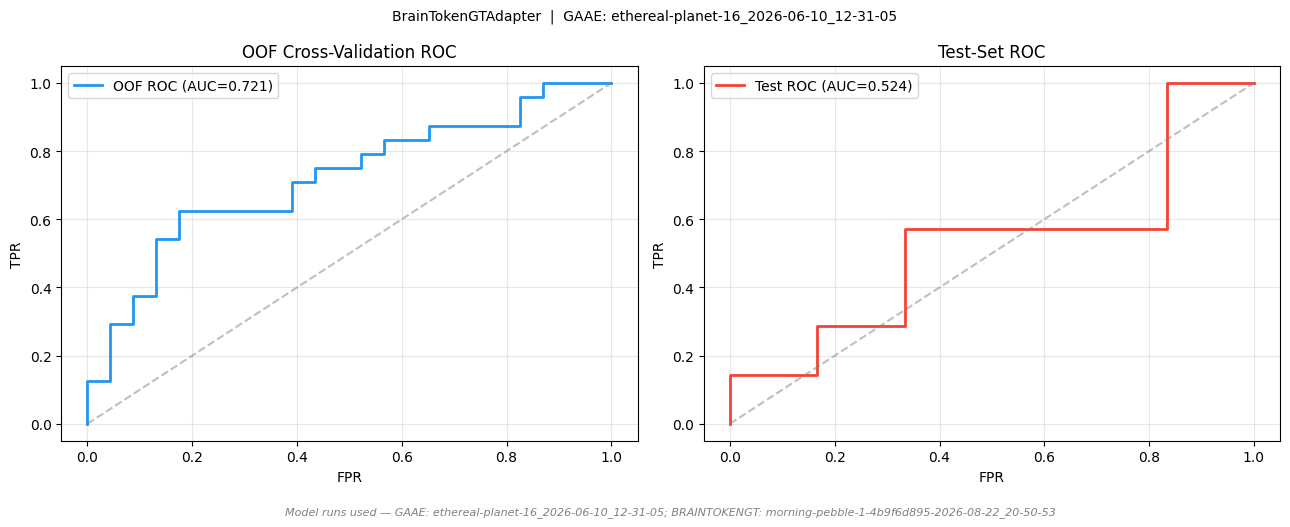

In [21]:
fig = plot_oof_test_roc(
    OOF_TARGETS, OOF_PROBS, TEST_METRICS['targets'], TEST_METRICS['probs'],
    title=f'{type(adapter).__name__}  |  GAAE: {GAAE_RUN_NAME}',
)
add_note(fig, list(fig.axes), format_model_runs_note(MODEL_RUNS))
plt.show()

## Early-Detection Curve: AUC vs. Number of Visits Used

Shared `early_detection_table`: for each N it restricts every test subject with `T >= N`
visits to their first N (via `truncate_to_n_visits`) and re-scores with `eval_split`.
Rows with fewer than 4 subjects or a single class are skipped. `N=1` = single-scan.

In [22]:
ED_ROWS = early_detection_table(
    TEST_BUNDLE, eval_split, truncate_to_n_visits,
    BEST_MODEL_STATE, ACTIVE_THRESHOLD, device=device,
)


Visits    N      AUC     Sens     Spec
----------------------------------------


     1   13   0.5952    0.857    0.333


     2   13   0.5476    0.571    0.333


     3    6   0.0000    0.000    0.333


## Conversion Probability Trajectories

Shared `trajectory_frame` builds per-visit `P(converter)` for each test subject with
>= 2 visits (via `per_visit_probs`); `plot_conversion_trajectories` renders the panels.

Trajectory data: 13 subjects


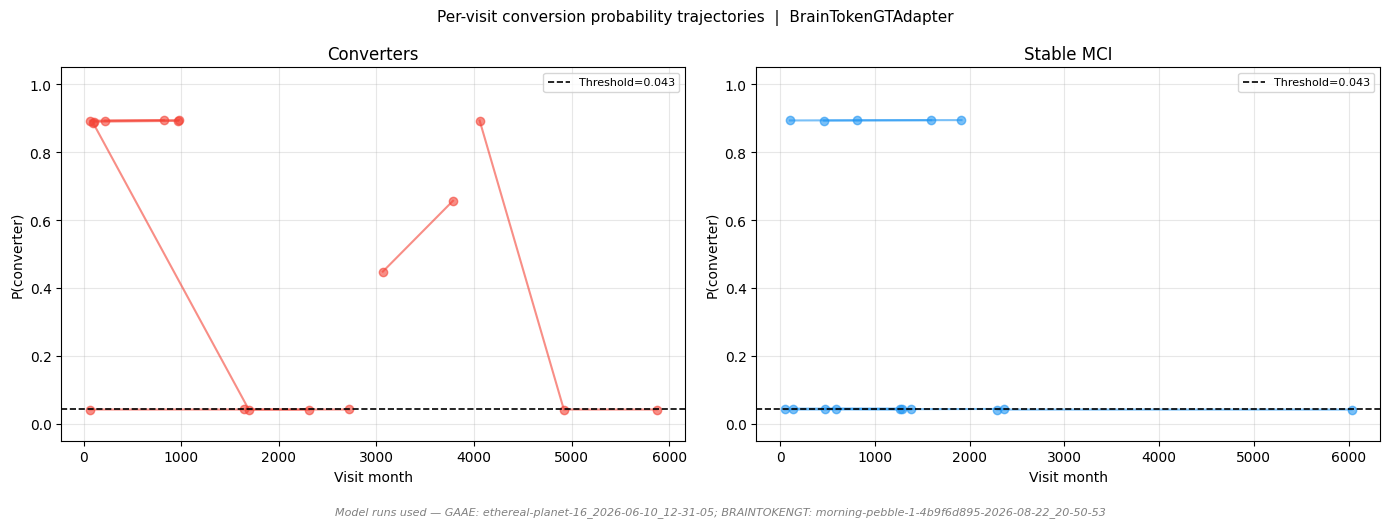

In [23]:
TRAJ_DF = trajectory_frame(TEST_BUNDLE, per_visit_probs, BEST_MODEL_STATE, device=device)
print(f"Trajectory data: {TRAJ_DF['pid'].nunique()} subjects")
fig = plot_conversion_trajectories(
    TRAJ_DF, ACTIVE_THRESHOLD,
    title=f'Per-visit conversion probability trajectories  |  {type(adapter).__name__}',
)
add_note(fig, list(fig.axes), format_model_runs_note(MODEL_RUNS))
plt.show()